# Crack Spread Time-Only Optuna - PTP Position Sizing

Optimizes a compact time-only GRU model on the 15-minute crack-spread master clock and adds a
4-class discrete `PredictionToPosition` head with actions
`sell_2=-1.0`, `sell_1=-0.5`, `buy_1=+0.5`, `buy_2=+1.0`, so validation is selected on trading
metrics, not just classification loss.


In [7]:
import gc
import json
import math
import sys
from pathlib import Path

ROOT_DIR = Path('/workspace')
CTAFLOW_REPO = ROOT_DIR / 'CTAFlow'
if str(CTAFLOW_REPO) not in sys.path:
    sys.path.append(str(CTAFLOW_REPO))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.optim as optim

from notebooks.crack_spread_tft_ptp_support import (
    PTPLoss,
    SharpeScheduler,
    TimeOnlyCrackPTP,
    build_crack_ptp_param_groups,
    build_time_only_samples,
    compute_trading_metrics,
    fit_final_crack_ptp,
    hybrid_selection_score,
    make_time_loaders,
    prepare_time_only_crack_data,
    split_time_samples,
)
from CTAFlow.models.deep_learning.multi_branch.tft.c_mmtft import PredictionToPosition, returns_to_classes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'
print(f'Using device: {device}')

def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DATA_ROOT = ROOT_DIR / 'model_data'
TICKERS = ('CL', 'HO', 'RB')
BAR_MINUTES = 15
TARGET_TICKER = 'CRACK'
TARGET_HORIZON_MINUTES = 60
DECODER_STEPS = TARGET_HORIZON_MINUTES // BAR_MINUTES
VAL_START = pd.Timestamp('2024-01-01')
TARGET_MODE = 'logret'
TARGET_COL = f'y_fwd_{DECODER_STEPS}'
SESSION_ONLY = True
SAMPLE_SESSION = None
SAMPLE_STRIDE = 4
LOOKBACK_STEPS_CHOICES = [24, 32, 48]
PREVIEW_LOOKBACK_STEPS = 32
MAX_TRAIN_SAMPLES = 100000
MAX_VAL_SAMPLES = 23000
N_TRIALS = 40
SHOW_OPTUNA_PROGRESS_BAR = False  # notebook tqdm/ipywidgets can crash some kernels
NUM_EPOCHS = 20
WARMUP_EPOCHS = 4
RESULTS_PATH = Path('artifacts') / 'crack_spread_time_only_ptp'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
STUDY_NAME = (
    f"crack_spread_time_only_ptp_{TARGET_TICKER.lower()}_"
    f"{BAR_MINUTES}m_{TARGET_HORIZON_MINUTES}m"
)


Using device: cuda


Data summary:
  rows=313,451
  compact_time_features=72
  target_ticker=CRACK
  target_horizon_minutes=60
  architecture=time_only_gru_attn_ptp
  ptp_actions=('sell_2', 'sell_1', 'buy_1', 'buy_2')
  ptp_levels=(-1.0, -0.5, 0.5, 1.0)
  target_col=y_fwd_4
Target class counts (outer=1.0): [ 23089 131136 135966  23256]
Cached preview samples: train=41,641, val=8,251


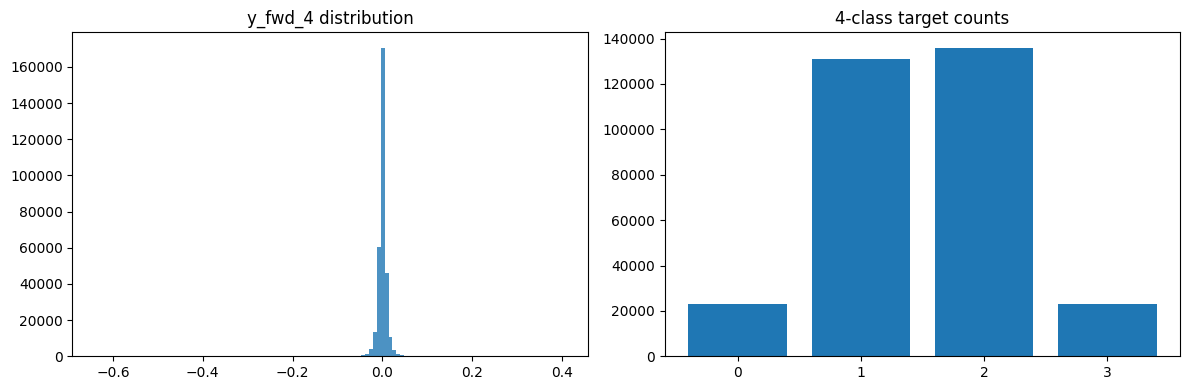

In [8]:
prep, model_df, train_mask, target_cols, feature_cols = prepare_time_only_crack_data(
    data_root=DATA_ROOT,
    tickers=TICKERS,
    bar_minutes=BAR_MINUTES,
    target_mode=TARGET_MODE,
    target_horizon_minutes=TARGET_HORIZON_MINUTES,
    target_ticker=TARGET_TICKER,
)

print('Data summary:')
print(f'  rows={len(model_df):,}')
print(f'  compact_time_features={len(feature_cols)}')
print(f'  target_ticker={TARGET_TICKER}')
print(f'  target_horizon_minutes={TARGET_HORIZON_MINUTES}')
print(f'  architecture=time_only_gru_attn_ptp')
print(f'  ptp_actions={PredictionToPosition.ACTION_LABELS}')
print(f'  ptp_levels={PredictionToPosition.DEFAULT_POSITION_LEVELS}')
print(f'  target_col={TARGET_COL}')

target_series = model_df[TARGET_COL].dropna()
target_labels = returns_to_classes(torch.tensor(target_series.values, dtype=torch.float32), outer=1.0).numpy()
print('Target class counts (outer=1.0):', np.bincount(target_labels, minlength=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target_series.values, bins=120, alpha=0.8)
axes[0].set_title(f'{TARGET_COL} distribution')
axes[1].bar(np.arange(4), np.bincount(target_labels, minlength=4))
axes[1].set_title('4-class target counts')
axes[1].set_xticks(np.arange(4))
plt.tight_layout()

WINDOW_CACHE = {}

def get_train_val_samples(lookback_steps: int):
    lookback_steps = int(lookback_steps)
    cache_key = lookback_steps
    if cache_key not in WINDOW_CACHE:
        samples = build_time_only_samples(
            df_out=model_df,
            target_col=TARGET_COL,
            feature_cols=feature_cols,
            lookback=lookback_steps,
            session_only=SESSION_ONLY,
            sample_session=SAMPLE_SESSION,
            stride=SAMPLE_STRIDE,
        )
        train_samples, val_samples = split_time_samples(
            samples,
            val_start=VAL_START,
            max_train_samples=MAX_TRAIN_SAMPLES,
            max_val_samples=MAX_VAL_SAMPLES,
        )
        WINDOW_CACHE[cache_key] = (train_samples, val_samples)
    return WINDOW_CACHE[cache_key]

train_preview, val_preview = get_train_val_samples(PREVIEW_LOOKBACK_STEPS)
print(f'Cached preview samples: train={len(train_preview):,}, val={len(val_preview):,}')


In [9]:
def objective(trial: optuna.Trial) -> float:
    lookback_steps = trial.suggest_categorical('lookback_steps', LOOKBACK_STEPS_CHOICES)
    hidden = trial.suggest_categorical('hidden', [32, 64, 96])
    n_layers = trial.suggest_int('n_layers', 1, 2)
    dropout = trial.suggest_float('dropout', 0.05, 0.30)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 2e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 48, 64])
    max_norm = trial.suggest_float('max_norm', 0.5, 1.0)

    ptp_temperature = trial.suggest_float('ptp_temperature', 1.0, 3.0)
    ptp_lr_scale = trial.suggest_float('ptp_lr_scale', 0.5, 1.5)
    ce_weight = trial.suggest_float('ce_weight', 0.3, 2.0, log=True)
    pnl_weight = trial.suggest_float('pnl_weight', 0.3, 2.0, log=True)
    profit_scale = trial.suggest_float('profit_scale', 25.0, 200.0)
    outer_threshold = trial.suggest_float('outer_threshold', 0.75, 1.5)

    tc_cost = trial.suggest_float('tc_cost', 5e-5, 5e-4, log=True)
    init_direction_weight = trial.suggest_float('init_direction_weight', 0.5, 1.5)
    final_direction_weight = trial.suggest_float('final_direction_weight', 0.05, 0.3)
    init_reg_weight = trial.suggest_float('init_reg_weight', 0.1, 0.5)
    target_exposure = trial.suggest_float('target_exposure', 0.5, 1.0)
    downside_vol_weight = trial.suggest_float('downside_vol_weight', 0.02, 0.75, log=True)
    holding_weight = trial.suggest_float('holding_weight', 0.0, 0.5)
    exposure_asymmetry = trial.suggest_float('exposure_asymmetry', 1.0, 6.0)

    try:
        train_samples, val_samples = get_train_val_samples(lookback_steps)
        train_loader, val_loader = make_time_loaders(
            train_samples=train_samples,
            val_samples=val_samples,
            batch_size=batch_size,
            num_workers=0,
            return_metadata=False,
        )
    except Exception as exc:
        print(f'Dataloader failed: {exc}')
        return -1e9

    model = TimeOnlyCrackPTP(
        in_channels=len(feature_cols),
        hidden=hidden,
        layers=n_layers,
        ptp_temperature=ptp_temperature,
        dropout=dropout,
    ).to(device)

    loss_fn = PTPLoss(
        ce_weight=ce_weight,
        pnl_weight=pnl_weight,
        profit_scale=profit_scale,
        outer_threshold=outer_threshold,
        tc_cost=tc_cost,
        direction_weight=init_direction_weight,
        reg_weight=init_reg_weight,
        target_exposure=target_exposure,
        use_sortino=True,
        downside_vol_weight=downside_vol_weight,
        tc_in_sharpe=True,
        holding_weight=holding_weight,
        exposure_asymmetry=exposure_asymmetry,
    ).to(device)

    optimizer = optim.AdamW(
        build_crack_ptp_param_groups(
            model,
            base_lr=learning_rate,
            weight_decay=weight_decay,
            ptp_lr_scale=ptp_lr_scale,
        )
    )
    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=learning_rate * 0.05,
    )
    sharpe_sched = SharpeScheduler(
        warmup_epochs=WARMUP_EPOCHS,
        total_epochs=NUM_EPOCHS,
        initial_direction_weight=init_direction_weight,
        final_direction_weight=final_direction_weight,
        initial_reg_weight=init_reg_weight,
        final_reg_weight=0.05,
        initial_target_exposure=0.5,
        final_target_exposure=target_exposure,
        initial_holding_weight=0.0,
        final_holding_weight=holding_weight,
    )
    scaler = torch.amp.GradScaler() if USE_AMP else None

    best_score = -1e9
    patience = 0
    prev_val_loss = None

    from notebooks.crack_spread_tft_ptp_support import train_epoch_crack_ptp, evaluate_crack_ptp

    for epoch in range(NUM_EPOCHS):
        sharpe_sched.step(epoch, loss_fn.trading_loss)
        train_loss, _ = train_epoch_crack_ptp(
            model=model,
            loader=train_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
            max_norm=max_norm,
            aux_weight=0.0,
            scaler=scaler,
        )
        val_metrics = evaluate_crack_ptp(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            device=device,
            aux_weight=0.0,
        )
        lr_scheduler.step()
        val_score = hybrid_selection_score(val_metrics, len(val_loader.dataset))

        if math.isnan(val_metrics['loss']) or math.isinf(val_metrics['loss']) or val_metrics['loss'] > 100.0:
            return best_score if best_score > -1e9 else -1e9
        if prev_val_loss is not None and epoch >= 3 and val_metrics['loss'] > abs(prev_val_loss) * 5.0:
            return best_score if best_score > -1e9 else -1e9
        prev_val_loss = val_metrics['loss']

        print(
            f"E{epoch + 1:02d} | Score {val_score:.4f} | Sharpe {val_metrics['sharpe']:.3f} | "
            f"Sortino {val_metrics['sortino']:.3f} | PF {val_metrics['profit_factor']:.3f} | "
            f"ClsAcc {val_metrics.get('cls_accuracy', 0.0):.2f}"
        )

        if epoch >= WARMUP_EPOCHS and val_score > best_score:
            best_score = val_score
            patience = 0
            trial.set_user_attr('final_selection_score', float(val_score))
            trial.set_user_attr('final_sharpe', float(val_metrics['sharpe']))
            trial.set_user_attr('final_sortino', float(val_metrics['sortino']))
            trial.set_user_attr('final_pf', float(val_metrics['profit_factor']))
            trial.set_user_attr('final_cls_acc', float(val_metrics.get('cls_accuracy', 0.0)))
            trial.set_user_attr('lookback_steps', int(lookback_steps))
        elif epoch >= WARMUP_EPOCHS:
            patience += 1

        trial.report(val_score, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if patience >= 6:
            break

    del model, optimizer, loss_fn, train_loader, val_loader
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return best_score


In [ ]:
study = optuna.create_study(
    study_name=STUDY_NAME,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=4),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=SHOW_OPTUNA_PROGRESS_BAR, gc_after_trial=True)

best_trial = study.best_trial
best_params = dict(best_trial.params)
best_params['best_value'] = best_trial.value
print('Best trial:', best_trial.number)
print(json.dumps(best_params, indent=2, default=str))

joblib.dump(study, RESULTS_PATH / f'{STUDY_NAME}_study.pkl')
df_trials = study.trials_dataframe()
df_trials.to_csv(RESULTS_PATH / f'{STUDY_NAME}_trials.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
valid_trials = df_trials[df_trials['state'] == 'COMPLETE']
axes[0].plot(valid_trials.index, valid_trials['value'], 'o-', alpha=0.7)
axes[0].set_title('Optimization history')
if 'params_lookback_steps' in valid_trials.columns:
    axes[1].scatter(valid_trials['params_lookback_steps'], valid_trials['value'], c=valid_trials.index, cmap='viridis', s=70)
    axes[1].set_xlabel('lookback_steps')
axes[1].set_title('Score vs lookback_steps')
plt.tight_layout()


[I 2026-04-13 22:15:12,800] A new study created in memory with name: crack_spread_time_only_ptp_crack_15m_60m


E01 | Score 1.2245 | Sharpe 0.695 | Sortino 0.908 | PF 1.027 | ClsAcc 32.97
E02 | Score -0.8914 | Sharpe -0.384 | Sortino -0.485 | PF 0.985 | ClsAcc 33.69
E03 | Score 0.7156 | Sharpe 0.252 | Sortino 0.328 | PF 1.010 | ClsAcc 35.98
E04 | Score 1.0989 | Sharpe 0.580 | Sortino 0.722 | PF 1.024 | ClsAcc 35.58
E05 | Score 3.2665 | Sharpe 3.297 | Sortino 4.276 | PF 1.140 | ClsAcc 33.97
E06 | Score 1.1465 | Sharpe 0.611 | Sortino 0.774 | PF 1.025 | ClsAcc 33.45
E07 | Score 1.3806 | Sharpe 0.877 | Sortino 1.099 | PF 1.036 | ClsAcc 35.33
E08 | Score 1.0415 | Sharpe 0.511 | Sortino 0.651 | PF 1.021 | ClsAcc 32.98
E09 | Score 1.6163 | Sharpe 1.170 | Sortino 1.448 | PF 1.049 | ClsAcc 36.10
E10 | Score 1.4637 | Sharpe 0.966 | Sortino 1.218 | PF 1.040 | ClsAcc 34.03


[I 2026-04-13 22:18:34,875] Trial 0 finished with value: 3.266497410028609 and parameters: {'lookback_steps': 32, 'hidden': 32, 'n_layers': 1, 'dropout': 0.2665440364437338, 'learning_rate': 0.0006054365855469249, 'weight_decay': 0.000814829321010529, 'batch_size': 48, 'max_norm': 0.6061695553391381, 'ptp_temperature': 1.3636499344142012, 'ptp_lr_scale': 0.6834045098534338, 'ce_weight': 0.5343048274530411, 'pnl_weight': 0.8118441500491741, 'profit_scale': 100.59037826237027, 'outer_threshold': 0.9684218551485314, 'tc_cost': 0.00020456102872218906, 'init_direction_weight': 0.6394938606520418, 'final_direction_weight': 0.12303616213380454, 'init_reg_weight': 0.2465447373174767, 'target_exposure': 0.728034992108518, 'downside_vol_weight': 0.3442877017118504, 'holding_weight': 0.09983689107917987, 'exposure_asymmetry': 3.571172192068058}. Best is trial 0 with value: 3.266497410028609.


E11 | Score 1.6761 | Sharpe 1.204 | Sortino 1.554 | PF 1.050 | ClsAcc 33.01
E01 | Score 1.5163 | Sharpe 1.065 | Sortino 1.445 | PF 1.041 | ClsAcc 39.78
E02 | Score 1.5017 | Sharpe 1.013 | Sortino 1.371 | PF 1.040 | ClsAcc 37.78
E03 | Score -0.8059 | Sharpe -0.325 | Sortino -0.425 | PF 0.987 | ClsAcc 37.01
E04 | Score 2.3630 | Sharpe 2.057 | Sortino 2.843 | PF 1.082 | ClsAcc 39.03
E05 | Score 0.9255 | Sharpe 0.413 | Sortino 0.557 | PF 1.017 | ClsAcc 36.69
E06 | Score 1.8890 | Sharpe 1.485 | Sortino 1.981 | PF 1.061 | ClsAcc 39.47
E07 | Score 2.1811 | Sharpe 1.766 | Sortino 2.480 | PF 1.074 | ClsAcc 35.64
E08 | Score -0.9280 | Sharpe -0.421 | Sortino -0.554 | PF 0.983 | ClsAcc 37.20
E09 | Score 1.2361 | Sharpe 0.698 | Sortino 0.946 | PF 1.028 | ClsAcc 34.21
E10 | Score -0.2849 | Sharpe -0.045 | Sortino -0.058 | PF 0.998 | ClsAcc 38.06
E11 | Score 2.9880 | Sharpe 2.836 | Sortino 3.900 | PF 1.122 | ClsAcc 38.69
E12 | Score 2.4272 | Sharpe 2.125 | Sortino 2.879 | PF 1.090 | ClsAcc 37.75
E13

[I 2026-04-13 22:26:30,031] Trial 1 finished with value: 2.9880066908793834 and parameters: {'lookback_steps': 48, 'hidden': 96, 'n_layers': 2, 'dropout': 0.2520993370291153, 'learning_rate': 0.0002490643969382441, 'weight_decay': 1.834907204905544e-05, 'batch_size': 32, 'max_norm': 0.7475884550556351, 'ptp_temperature': 1.0687770422304368, 'ptp_lr_scale': 1.409320402078782, 'ce_weight': 0.49015376570470165, 'pnl_weight': 1.054336291901036, 'profit_scale': 79.54943831564691, 'outer_threshold': 1.140051015883358, 'tc_cost': 0.00017606794027339345, 'init_direction_weight': 0.684854455525527, 'final_direction_weight': 0.29239615694113963, 'init_reg_weight': 0.4100531293444458, 'target_exposure': 0.9697494707820946, 'downside_vol_weight': 0.5122904081486095, 'holding_weight': 0.29894998940554257, 'exposure_asymmetry': 5.609371175115584}. Best is trial 0 with value: 3.266497410028609.


E17 | Score 0.2384 | Sharpe 0.031 | Sortino 0.042 | PF 1.001 | ClsAcc 35.46
E01 | Score 1.5718 | Sharpe 1.133 | Sortino 1.515 | PF 1.044 | ClsAcc 41.21
E02 | Score 0.8449 | Sharpe 0.362 | Sortino 0.498 | PF 1.014 | ClsAcc 38.87
E03 | Score 0.9461 | Sharpe 0.481 | Sortino 0.633 | PF 1.018 | ClsAcc 42.54


In [ ]:
best = dict(study.best_trial.params)
lookback_steps = int(best['lookback_steps'])
train_samples, val_samples = get_train_val_samples(lookback_steps)
train_loader, val_loader = make_time_loaders(
    train_samples=train_samples,
    val_samples=val_samples,
    batch_size=int(best['batch_size']),
    num_workers=0,
    return_metadata=True,
)

final_model = TimeOnlyCrackPTP(
    in_channels=len(feature_cols),
    hidden=int(best['hidden']),
    layers=int(best['n_layers']),
    ptp_temperature=float(best['ptp_temperature']),
    dropout=float(best['dropout']),
).to(device)

loss_fn = PTPLoss(
    ce_weight=float(best['ce_weight']),
    pnl_weight=float(best['pnl_weight']),
    profit_scale=float(best['profit_scale']),
    outer_threshold=float(best['outer_threshold']),
    tc_cost=float(best['tc_cost']),
    direction_weight=float(best['init_direction_weight']),
    reg_weight=float(best['init_reg_weight']),
    target_exposure=float(best['target_exposure']),
    use_sortino=True,
    downside_vol_weight=float(best['downside_vol_weight']),
    tc_in_sharpe=True,
    holding_weight=float(best['holding_weight']),
    exposure_asymmetry=float(best['exposure_asymmetry']),
).to(device)
optimizer = optim.AdamW(
    build_crack_ptp_param_groups(
        final_model,
        base_lr=float(best['learning_rate']),
        weight_decay=float(best['weight_decay']),
        ptp_lr_scale=float(best['ptp_lr_scale']),
    )
)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(NUM_EPOCHS + 8, 20),
    eta_min=float(best['learning_rate']) * 0.05,
)
sharpe_sched = SharpeScheduler(
    warmup_epochs=WARMUP_EPOCHS,
    total_epochs=max(NUM_EPOCHS + 8, 20),
    initial_direction_weight=float(best['init_direction_weight']),
    final_direction_weight=float(best['final_direction_weight']),
    initial_reg_weight=float(best['init_reg_weight']),
    final_reg_weight=0.05,
    initial_target_exposure=0.5,
    final_target_exposure=float(best['target_exposure']),
    initial_holding_weight=0.0,
    final_holding_weight=float(best['holding_weight']),
)
scaler = torch.amp.GradScaler() if USE_AMP else None

result = fit_final_crack_ptp(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=lr_scheduler,
    sharpe_scheduler=sharpe_sched,
    device=device,
    num_epochs=max(NUM_EPOCHS + 8, 20),
    warmup_epochs=WARMUP_EPOCHS,
    max_norm=float(best['max_norm']),
    aux_weight=0.0,
    scaler=scaler,
)
if result.best_state is not None:
    final_model.load_state_dict(result.best_state)

print('Best final score:', result.best_score)
print('Best validation metrics:')
print(json.dumps(result.best_metrics, indent=2, default=float))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(result.history['train_loss'], label='train')
axes[0, 0].plot(result.history['val_loss'], label='val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 1].plot(result.history['val_score'])
axes[0, 1].set_title('Validation selection score')
axes[1, 0].plot(result.history['val_sharpe'], label='sharpe')
axes[1, 0].plot(result.history['val_sortino'], label='sortino')
axes[1, 0].legend()
axes[1, 0].set_title('Trading metrics')
axes[1, 1].plot(result.history['val_cls_acc'])
axes[1, 1].set_title('Validation class accuracy')
plt.tight_layout()

save_dict = {
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_metrics': result.best_metrics,
    'best_score': result.best_score,
    'best_params': best,
    'target_col': TARGET_COL,
    'target_ticker': TARGET_TICKER,
    'tickers': TICKERS,
    'bar_minutes': BAR_MINUTES,
    'target_horizon_minutes': TARGET_HORIZON_MINUTES,
    'lookback_steps': lookback_steps,
    'lookback_steps_choices': LOOKBACK_STEPS_CHOICES,
    'feature_cols': feature_cols,
    'model_arch': 'time_only_gru_attn_ptp',
    'ptp_action_labels': PredictionToPosition.ACTION_LABELS,
    'ptp_position_levels': PredictionToPosition.DEFAULT_POSITION_LEVELS,
}
torch.save(save_dict, RESULTS_PATH / f'{STUDY_NAME}_best_model.pth')


In [ ]:
EXPORT_DATASET_PATH = RESULTS_PATH / f'{STUDY_NAME}_optimized_datasets'
EXPORT_DATASET_PATH.mkdir(parents=True, exist_ok=True)

def _time_sample_manifest(samples):
    return pd.DataFrame({
        'anchor_ts': pd.to_datetime([sample['anchor_ts'] for sample in samples]),
        'target_end_ts': pd.to_datetime([sample['target_end_ts'] for sample in samples]),
        'date': pd.to_datetime([sample['date'] for sample in samples]),
        'target': np.asarray([sample['target'] for sample in samples], dtype=np.float32),
    })

def _export_time_split(split_name: str, samples):
    if not samples:
        raise ValueError(f'No samples available for split={split_name!r}')

    features = np.stack([np.asarray(sample['features'], dtype=np.float32) for sample in samples]).astype(np.float32)
    targets = np.asarray([sample['target'] for sample in samples], dtype=np.float32)
    anchor_ts = np.asarray([pd.Timestamp(sample['anchor_ts']).isoformat() for sample in samples], dtype=str)
    target_end_ts = np.asarray([
        pd.Timestamp(sample['target_end_ts']).isoformat() if pd.notna(sample['target_end_ts']) else ''
        for sample in samples
    ], dtype=str)

    np.savez_compressed(
        EXPORT_DATASET_PATH / f'{STUDY_NAME}_{split_name}_time_only_windows.npz',
        features=features,
        targets=targets,
        anchor_ts=anchor_ts,
        target_end_ts=target_end_ts,
        feature_cols=np.asarray(feature_cols, dtype=str),
        lookback_steps=np.asarray([lookback_steps], dtype=np.int32),
    )

    manifest = _time_sample_manifest(samples)
    manifest.to_csv(EXPORT_DATASET_PATH / f'{STUDY_NAME}_{split_name}_manifest.csv', index=False)
    joblib.dump(samples, EXPORT_DATASET_PATH / f'{STUDY_NAME}_{split_name}_samples.joblib')
    return manifest

train_manifest = _export_time_split('train', train_samples)
val_manifest = _export_time_split('val', val_samples)

export_meta = {
    'study_name': STUDY_NAME,
    'target_col': TARGET_COL,
    'target_ticker': TARGET_TICKER,
    'tickers': TICKERS,
    'bar_minutes': BAR_MINUTES,
    'target_horizon_minutes': TARGET_HORIZON_MINUTES,
    'lookback_steps': lookback_steps,
    'feature_cols': feature_cols,
    'best_params': best,
    'train_samples': len(train_samples),
    'val_samples': len(val_samples),
}
with open(EXPORT_DATASET_PATH / f'{STUDY_NAME}_optimized_dataset_meta.json', 'w') as f:
    json.dump(export_meta, f, indent=2, default=float)

print(f'Exported optimized datasets to: {EXPORT_DATASET_PATH}')
for path in sorted(EXPORT_DATASET_PATH.glob(f'{STUDY_NAME}_*')):
    print(f'  - {path.name}')

display(train_manifest.head(3))
display(val_manifest.head(3))


In [ ]:
from notebooks.crack_spread_tft_ptp_support import batch_to_device

final_model.eval()
all_positions = []
all_returns = []
all_logits = []
all_timestamps = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets = batch_to_device(batch, device)
        position, logits, _ = final_model(**inputs)
        all_positions.append(position.detach().cpu().numpy().reshape(-1))
        all_returns.append(targets.detach().cpu().numpy().reshape(-1))
        all_logits.append(logits.detach().cpu().numpy())
        all_timestamps.extend(batch['_anchor_ts'])

val_positions = np.concatenate(all_positions)
val_returns = np.concatenate(all_returns)
val_logits = np.concatenate(all_logits)
val_metrics = compute_trading_metrics(val_positions, val_returns, logits=val_logits, outer_threshold=float(best['outer_threshold']))
print(json.dumps(val_metrics, indent=2, default=float))

bt_df = pd.DataFrame({
    'anchor_ts': pd.to_datetime(all_timestamps),
    'position': val_positions,
    'forward_return': val_returns,
})
bt_df['strategy_return'] = bt_df['position'] * bt_df['forward_return']
bt_df['cum_strategy_return'] = bt_df['strategy_return'].cumsum()
bt_df['cum_forward_return'] = bt_df['forward_return'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(bt_df['anchor_ts'], bt_df['cum_strategy_return'], label='strategy')
axes[0].plot(bt_df['anchor_ts'], bt_df['cum_forward_return'], label='buy_hold', alpha=0.7)
axes[0].legend()
axes[0].set_title('Validation cumulative returns')
axes[1].plot(bt_df['anchor_ts'], bt_df['position'], alpha=0.8)
axes[1].set_title('Validation position path')
plt.tight_layout()

bt_df.to_csv(RESULTS_PATH / f'{STUDY_NAME}_validation_backtest.csv', index=False)
